# G배수지에서 나가는 물 예측
**유출유량 시계열 데이터에 슬라이딩 윈도우 기법을 이용한 LSTM**
- 60분 학습, 다음 10분 예측.
- 현재 오버피팅이 나는 중이다. 학습데이터 차수는 60차원. 윈도우 폭을 줄여서 학습데이터 차수를 줄여야하는지?

**Savitzky-Golay Filter를 사용하여 데이터를 부드럽게 전처리**
- 본래 삐죽빼죽거리는 signal 데이터를 부드럽게 만들기위해 사용하는 필터.
- 윈도우를 슬라이딩하면서 윈도우 안의 데이터를 low degree 다항식에 fitting해서 전처리.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from scipy.signal import savgol_filter

**Params**

In [589]:
#data slicing
start = 1440 * 1 # +1일차
end = start + 1440 * 2 #일간

#Sliding window config
window_size=60
forecast_size=20
lead_time=1 #forecast_size 보다 커지면 윈도우 사이에 갭이 생기므로 주의

#LSTM config
units = 20

#learning config
epochs=10
batch_size=16

In [590]:
g_resv_flow = pd.read_csv('../data/rawdata/53.csv')
g_resv_flow.columns = ['id', 'time', 'g_resv_flow', 'drop']
del g_resv_flow['id']
del g_resv_flow['drop']

**2일차부터 시작해서 3일분의 데이터를 사용하여 학습 및 예측할 예정**

In [591]:
g_resv_flow_temp = g_resv_flow[start:end]

time = g_resv_flow_temp['time']
time = pd.to_datetime(time)
g_resv_flow_temp['time'] = time


**Preprocessing (Savitzky-Golay Filter)**
- https://en.wikipedia.org/wiki/Savitzky%E2%80%93Golay_filter 의 gif 참고
- 삐죽거리는 데이터를 스무스하게 만들어주는 전처리 방식 
- 슬라이딩 윈도우 기법으로 윈도우 프레임 안에 있는 데이터들을 low-degree polynomial 그래프에 맞춰서 전처리 해준다. 
- savgol_filter(data, window_length=윈도우 너비, polyorder=다항식 차수)
- 아래는 2차 다항식을 이용했다. 그래프에 작은 포물선들이 보일 것.

In [592]:
g_resv_flow_temp['savgol_smooth'] = savgol_filter(g_resv_flow_temp['g_resv_flow'], window_length=31, polyorder=1)

**Check Data After Processing**

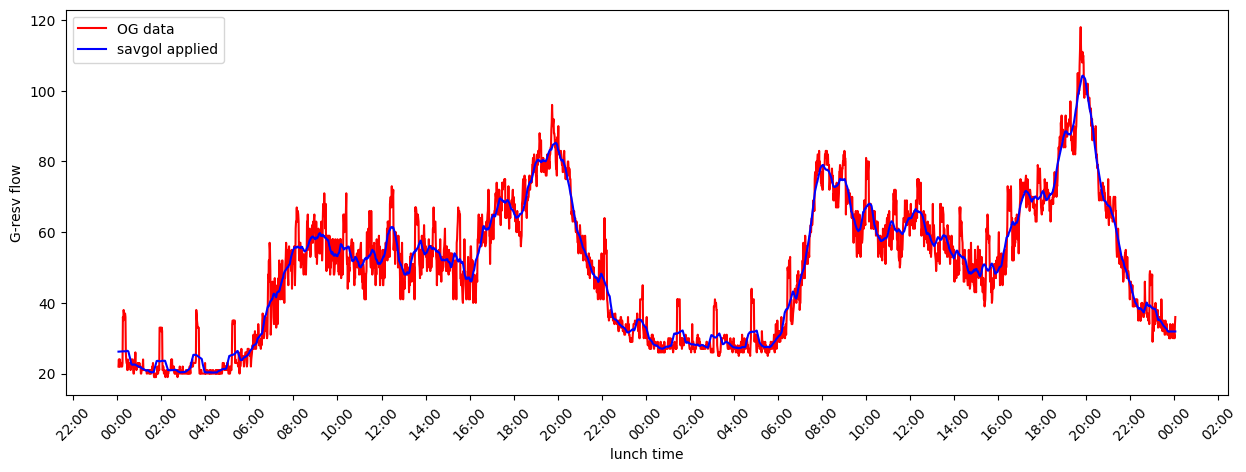

In [593]:
fig, ax = plt.subplots(figsize=(15,5))

#=========g_resv_flow
#=========g_resv_flow
#=========g_resv_flow
ax.plot(time, g_resv_flow_temp['g_resv_flow'], label='OG data', color='red')
ax.plot(time, g_resv_flow_temp['savgol_smooth'], label='savgol applied', color='blue')

#=========misc config
#=========misc config
#=========misc config
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel('lunch time')
ax.set_ylabel('G-resv flow')
ax.legend()

plt.xticks(rotation=45)

plt.show()

**Normalization**

In [594]:
scaler = MinMaxScaler(feature_range=(0,1))

column_to_normalize = g_resv_flow_temp.columns[-1]
g_resv_flow_temp['normalized_flow'] = scaler.fit_transform(g_resv_flow_temp[[column_to_normalize]])

**Create Sliding Window Dataset**
- 슬라이딩 윈도우 코드를 수정했습니다. 기존에 1분씩 윈도우를 밀던걸 lead_time이라는 변수를 지정하여 그만큼 밀어내도록 합니다. 과적합을 방지하기 위해 작성해보았습니다. 

In [595]:
# X.shape = (60,1) y.shape = (10,1) => X는 60분 학습 데이터, y는 10분 예측 데이터. 1분이 1개의 feature로 들어간다.  
def create_sliding_windows(data, window_size=60, lead_time=1, forecast_size=10):
    #기존 분단위 슬라이딩 코드
    #stop_index = len(data) - window_size - forecast_size -lead_time
    #X = [data[i:i+window_size] for i in range(stop_index)]
    #y = [data[i+window_size+lead_time : i+window_size+forecast_size+lead_time] for i in range(stop_index)]
    
    #신규 lead_time분단위 슬라이딩 코드: 윈도우를 1분씩 뒤로 미는 것이 아니라 x분씩 뒤로 민다. 과도한 학습을 방지하기 위해 작성해보았음.
    stop_index = int((len(data) - window_size - forecast_size)/lead_time)
    X = [data[i*lead_time : i*lead_time+window_size] for i in range(stop_index)]
    y = [data[i*lead_time+window_size : i*lead_time+window_size+forecast_size] for i in range(stop_index)]

    return np.array(X), np.array(y)

g_resv_flow_values = g_resv_flow_temp['normalized_flow'].values
X,y = create_sliding_windows(data=g_resv_flow_values, window_size=window_size, lead_time=lead_time, forecast_size=forecast_size)
X = X.reshape((X.shape[0], X.shape[1],1))

In [596]:
stop_index = int((len(g_resv_flow_values) - window_size - forecast_size)/lead_time)
len(g_resv_flow_values)
stop_index, X.shape, y.shape

(2800, (2800, 60, 1), (2800, 20))

**Train Test Split**

In [597]:
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [598]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2240, 60, 1), (560, 60, 1), (2240, 20), (560, 20))

In [599]:
#==========Univariate LSTM with MSE Loss
#==========Univariate LSTM with MSE Loss
#==========Univariate LSTM with MSE Loss
#define model
model = Sequential([
    #1층
    LSTM(units=units, activation='relu', input_shape=(window_size,1), return_sequences=False), #2층쓸거면 트루
    Dropout(0.4),
    #2층
    #LSTM(units=int(units/2), activation='relu', return_sequences=False),
    #Dropout(0.2),

    #Output = x분 예측
    Dense(forecast_size)
])

#use MSE for loss
model.compile(optimizer='adam', loss='mse')

#train
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size, #train sample/batch size = step per epoch
    validation_data=(X_test,y_test),
    verbose=1
)

y_pred_normalized = model.predict(X_test)

y_pred_original = scaler.inverse_transform(y_pred_normalized.reshape(-1,1).reshape(y_pred_normalized.shape))
y_test_original = scaler.inverse_transform(y_test.reshape(-1,1).reshape(y_test.shape))

mae = mean_absolute_error(y_test_original, y_pred_original)
print(f"--- Evaluation Result ---")
print(f"Mean Absolute Error: {mae:.2f} m^3/hour")
print(f"Interpretation: On average, our 10-minute prediction is off by {mae:.2f} m^3/hour.")

Epoch 1/10


c:\Users\user\miniconda3\envs\mypy\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0702 - val_loss: 0.0406
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0230 - val_loss: 0.0159
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0133 - val_loss: 0.0079
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0107 - val_loss: 0.0062
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0089 - val_loss: 0.0080
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0079 - val_loss: 0.0067
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0066 - val_loss: 0.0078
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0068 - val_loss: 0.0065
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0069 - val_loss: 0.0054
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0067 - val_loss: 0.0091
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
--- Evaluation Result ---
Mean Absolute Error: 5.51 m^3/hour
Interpretation: On average, our 10-minute predict

**Evaluation**

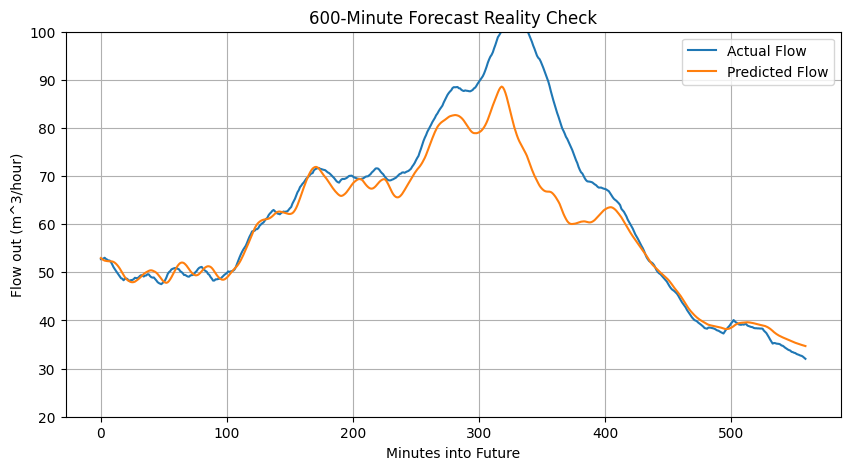

In [600]:
sample_idx0 = 10 * 0
interval = 60*10 #Max = total interval (minute) * 0.2
sample_idx1 = sample_idx0 + interval

#y_test_len = len(y_test_original[sample_idx0:sample_idx1,0])
#y_pred_len = len(y_pred_original[sample_idx0:sample_idx1,0])
#y_fore_len = len(y_pred_original[sample_idx0:sample_idx1:forecast_size].reshape(-1))
#plt.plot(range(1, 1+y_test_len), y_test_original[sample_idx0:sample_idx1,0], label='Actual Flow', marker='o')
#plt.plot(range(1, 1+y_pred_len), y_pred_original[sample_idx0:sample_idx1,0], label='Predicted Flow', marker='x', linestyle='--')
#plt.plot(range(1, 1+y_fore_len), y_pred_original[sample_idx0:sample_idx1:forecast_size].reshape(-1), label=f'{forecast_size}-min Predict')

y_test_flattened = y_test_original[:,0].flatten()
y_test_plot = y_test_flattened[sample_idx0 : sample_idx1]

y_pred_flattened = y_pred_original[:,0].flatten()
y_pred_plot = y_pred_flattened[sample_idx0 : sample_idx1]

plt.figure(figsize=(10, 5))


plt.plot(range(len(y_test_plot)), y_test_plot, label='Actual Flow')#, marker='o')
plt.plot(range(len(y_pred_plot)), y_pred_plot, label='Predicted Flow')#, marker='x')

plt.title(f"{interval}-Minute Forecast Reality Check")
plt.xlabel("Minutes into Future")
plt.ylabel("Flow out (m^3/hour)")
plt.legend()
plt.grid(True)
plt.ylim(20, 100) 
plt.show()

**분석**
- 60분 학습, 20분 예측, 10분 슬라이딩

In [601]:
y_test_flattened.shape, y_pred_flattened.shape

((560,), (560,))